# JuliaMag — GPU benchmark + standard problems on Colab

Runs the JuliaMag CUDA extension on a Colab GPU (choose a GPU runtime:
**Runtime → Change runtime type → GPU**, ideally T4/L4/A100). It installs Julia
and the package, verifies GPU correctness (fields, demag, DMI, STT, solvers all
vs CPU), runs µMAG Standard Problem 4 entirely on the GPU, runs the **full set of
µMAG standard problems** (2, 4, 5) saving each one's data table and figure, and
benchmarks the effective field and a relax step CPU vs GPU across mesh sizes.

The physics is validated to floating-point precision against the CPU; the point
of running here is the **speedup on a modern GPU** (a Quadro P1000 already gives
~3x on the effective field — a current GPU should do much better).

## 1. Check the GPU

In [1]:
!nvidia-smi

Thu Aug 27 03:04:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Install Julia

Installs a recent Julia into `/usr/local` so `julia` is on the PATH.

In [2]:
%%bash
set -e
JULIA_VER=1.11.3
JULIA_DIR=julia-${JULIA_VER}
if [ ! -x /usr/local/bin/julia ]; then
  wget -q https://julialang-s3.julialang.org/bin/linux/x64/${JULIA_VER%.*}/julia-${JULIA_VER}-linux-x86_64.tar.gz
  tar -xzf julia-${JULIA_VER}-linux-x86_64.tar.gz
  cp -r ${JULIA_DIR}/* /usr/local/
fi
julia --version

julia version 1.12.6


## 3. Get JuliaMag and install CUDA

Clones the repo and instantiates its project, then adds CUDA.jl (which downloads
its own CUDA toolkit artifacts). First run takes a few minutes to precompile.

In [3]:
%%bash
set -e
[ -d juliamag ] || git clone --depth 1 https://github.com/rlnovak/juliamag.git
cd juliamag
# CairoMakie, not Plots: Colab's NVIDIA driver ships a libglapi without
# `_glapi_tls_Current`, which breaks the Libglvnd -> GLFW -> GR_jll chain that
# Plots.jl loads unconditionally. CairoMakie is pure Cairo, no OpenGL.
julia --project=. -e 'using Pkg; Pkg.instantiate(); Pkg.add(["CUDA","CairoMakie","DelimitedFiles"]); using CUDA'

Cloning into 'juliamag'...
    Updating registry at `~/.julia/registries/General.toml`
   Installed SciMLJacobianOperators ─────────── v0.1.18
   Installed TimerOutputs ───────────────────── v0.5.29
   Installed SciMLLogging ───────────────────── v2.1.0
   Installed FindFirstFunctions ─────────────── v3.2.1
   Installed OrdinaryDiffEqRosenbrock ───────── v2.4.2
   Installed MaybeInplace ───────────────────── v0.1.8
   Installed OrdinaryDiffEqSDIRK ────────────── v2.8.1
   Installed AMD ────────────────────────────── v0.5.3
   Installed FFTW ───────────────────────────── v1.10.0
   Installed RecursiveArrayTools ────────────── v4.5.1
   Installed FunctionWrappers ───────────────── v1.1.3
   Installed NonlinearSolve ─────────────────── v4.21.1
   Installed IntelOpenMP_jll ────────────────── v2025.2.0+0
   Installed FastPower ──────────────────────── v1.5.0
   Installed FiniteDiff ─────────────────────── v2.33.0
   Installed OrdinaryDiffEqCore ─────────────── v4.14.1
   Installed Bracketin

In [4]:
%%bash
cd juliamag
julia --project=. -e 'using CUDA; println("functional: ", CUDA.functional()); CUDA.functional() && println(CUDA.name(CUDA.device()), "  cc ", CUDA.capability(CUDA.device()))'

functional: true
Tesla T4  cc 7.5.0


## 4. Correctness — fields, demag, DMI, STT, solvers (GPU vs CPU)

Runs the two verification scripts already in the repo. Every quantity must agree
with the CPU to floating-point precision (~1e-15).

In [5]:
%%bash
cd juliamag
julia --project=. examples/gpu_check.jl
echo '----------------------------------------'
julia --project=. examples/gpu_demag_check.jl

CUDA device: Tesla T4

Field-by-field CPU vs GPU agreement:
  exchange:   max rel diff = 3.17e-16
  anisotropy: max rel diff = 0.00e+00
  zeeman:     max rel diff = 0.00e+00
  torque:     max rel diff = 2.01e-16
  average:    Δ = 8.67e-19
  normalize:  max rel diff = 2.22e-16

Timing (exchange!, 100 calls):
  CPU: 0.3 ms   GPU: 1.5 ms   speedup: 0.2x

GPU check done.
----------------------------------------
CUDA device: Tesla T4

Accuracy (max rel diff CPU vs GPU):
  std4    cells=  2500   demag=6.76e-16   effective field=2.79e-16
  cube3D  cells= 16384   demag=4.73e-16   effective field=5.06e-16
  film    cells= 16384   demag=5.96e-16   effective field=4.45e-16

Timing — full effective field with demag (ms/call):
  cells     CPU(ms)   GPU(ms)   speedup
      4096     0.87      1.28   0.68x
     16384     3.28      1.53   2.14x
     65536    22.49      5.01   4.49x
    262144    87.44     12.24   7.14x
    524288   391.88     30.78   12.73x
   1048576   525.34     38.15   13.77x

GPU d

## 5. Standard Problem 4, entirely on the GPU

Relaxes the S-state and integrates the 1 ns switching on the GPU, writes a table
and (if a CPU reference table is present) the max deviation, and saves the plot.

In [6]:
%%bash
cd juliamag
# CPU reference table, so stdproblem4_gpu.jl can print the GPU-vs-CPU deviation.
# Run the CPU std4 under the main project (which now has Plots + DelimitedFiles).
[ -f examples/stdproblem4.txt ] || julia --project=. examples/stdproblem4.jl || true
julia --project=. examples/stdproblem4_gpu.jl

CUDA device: Tesla T4
Relaxing to the S-state on the GPU…
  relaxed after 332 steps, ⟨m⟩ = (0.9668, 0.1256, 0.0000)
Integrating the 1 ns switching on the GPU…
  t = 0.25 ns  ⟨m⟩ = (-0.6847, -0.4165, 0.0192)
  t = 0.50 ns  ⟨m⟩ = (-0.9180, -0.2275, 0.0470)
  t = 0.75 ns  ⟨m⟩ = (-0.9413, 0.2751, -0.0454)
  t = 1.00 ns  ⟨m⟩ = (-0.9850, 0.1227, 0.0434)
Wrote table → /content/juliamag/examples/stdproblem4_gpu.txt
Max |GPU - CPU| over the run: mx=3.41e-06 my=4.40e-06 mz=1.26e-06
Wrote figure → /content/juliamag/examples/stdproblem4_gpu.png


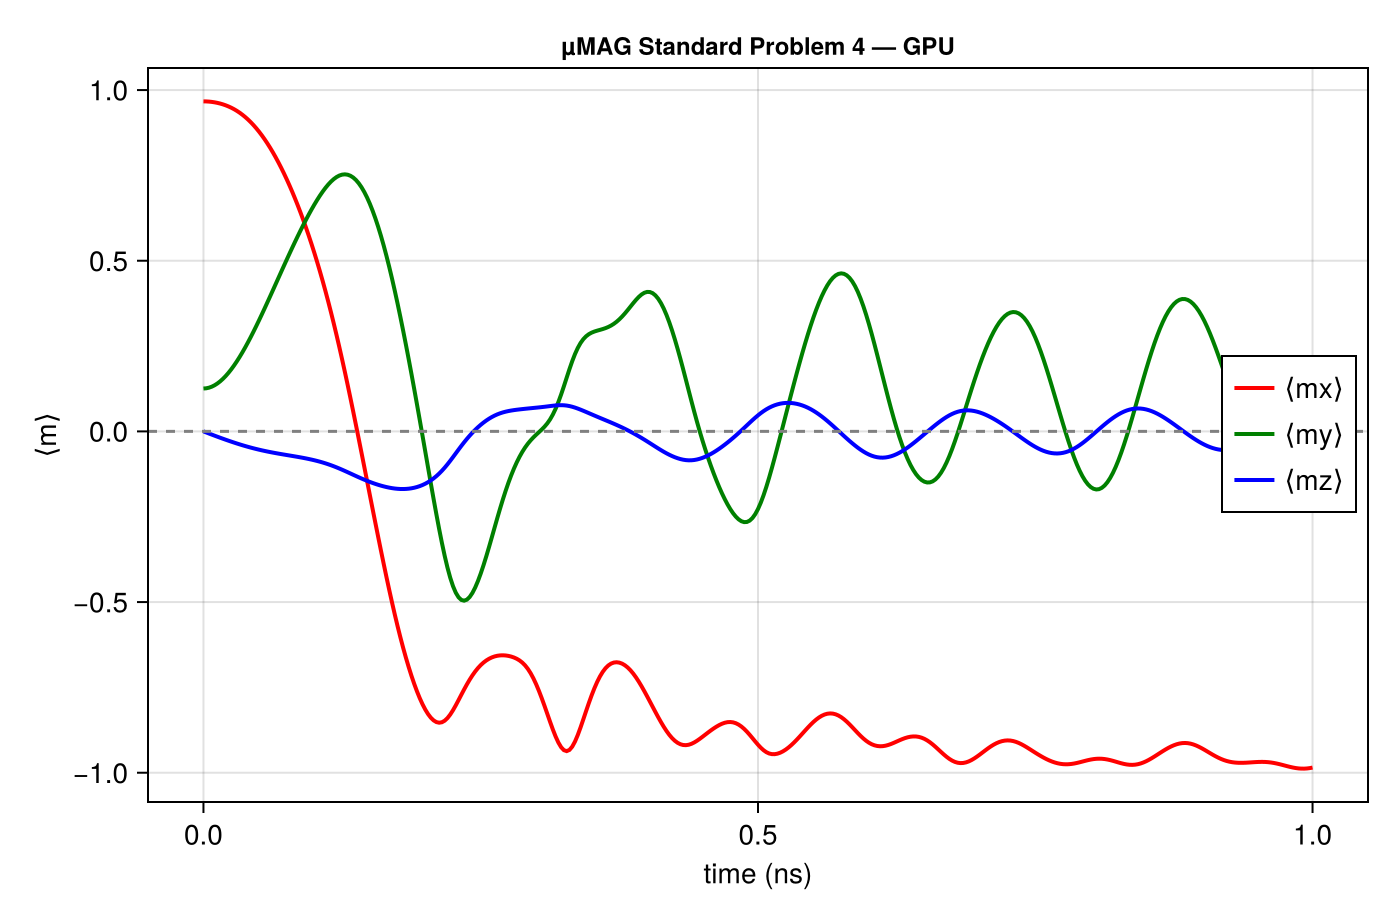

In [7]:
from IPython.display import Image
Image('juliamag/examples/stdproblem4_gpu.png')

## 6. All µMAG standard problems — tables + plots

Runs the full standard-problem set and saves each one's numeric data table and
figure:

- **SP2** — remanence vs. size (`stdproblem2.txt`, `stdproblem2_compare.png`) and
  the coercive/switching fields (`stdproblem2_hysteresis.txt`,
  `stdproblem2_hysteresis.png`), both compared to the OOMMF reference.
- **SP4** — dynamic reversal ⟨m⟩(t) (`stdproblem4.txt`, `stdproblem4.png`).
- **SP5** — Zhang–Li spin-transfer torque; the run below writes the ⟨m⟩(t) and
  core-position trajectory (`stdproblem5.txt`) and a plot (`stdproblem5.png`), and
  prints the final ⟨m⟩(1 ns) against the mumax3 reference.

These run on the CPU build (the standard-problem drivers use the energy minimizer
and the ODE integrator); they validate the physics and produce the reference
tables. The GPU sections above cover device execution and speed.

In [9]:
%%bash
cd juliamag
# SP2 (remanence) and SP2 hysteresis, SP4 dynamics — the repo drivers already
# write a .txt table and a .png figure each. Run them under the main project.
julia --project=. examples/stdproblem2.jl
julia --project=. examples/stdproblem2_hysteresis.jl
julia --project=. examples/stdproblem4.jl

# SP5 (Zhang-Li STT): relax a vortex, drive it with a current for 1 ns, and write
# the trajectory table + figure (the repo driver only prints the final ).
# NOTE: the script is written to /tmp, so `include` of the shim must use an
# absolute path (pwd() is .../juliamag from the `cd` above); a relative path would
# resolve against /tmp and fail.
cat > /tmp/sp5.jl <<'EOF'
using JuliaMag, Printf
include(joinpath(pwd(), "examples", "makie_shim.jl"))
mesh = Mesh((32,32,4), (100e-9/32, 100e-9/32, 10e-9/4))
mat  = Material(Msat=800e3, Aex=13e-12, alpha=0.1, pol=1.0, xi=0.05)
world = World(mesh, mat; demag=true)
m = setconfig(mesh, VortexConfig(mesh; circ=1, pol=1))
mn = Minimizer(world, m; stopdm=1e-6); minimize!(mn; maxsteps=20000); m = mn.m
@printf("relaxed vortex, =(%.4f,%.4f,%.4f)\n", average(m)...)

rhs!(dm,mm) = (B=world._Bbuf; effectivefield!(B,mm,world); torque!(dm,mm,B,mat.alpha);
               zhanglitorque!(dm,mm,mesh,mat,(1e12,0.0,0.0); add=true); dm)
function rk4!(m,dt,n)
  k1=similar(m);k2=similar(m);k3=similar(m);k4=similar(m);t=similar(m)
  for _ in 1:n
    rhs!(k1,m); @. t=m+0.5dt*k1; normalize!(t); rhs!(k2,t)
    @. t=m+0.5dt*k2; normalize!(t); rhs!(k3,t); @. t=m+dt*k3; normalize!(t); rhs!(k4,t)
    @. m=m+(dt/6)*(k1+2k2+2k3+k4); normalize!(m)
  end
end
dt=5e-14; nchunk=50; per=round(Int,1e-9/dt)÷nchunk
ts=Float64[]; mxs=Float64[]; mys=Float64[]; mzs=Float64[]; cx=Float64[]; cy=Float64[]
for c in 0:nchunk
  c>0 && rk4!(m,dt,per)
  a=average(m); vx,vy,_,_=vortexcore(m,mesh)
  push!(ts,c*per*dt); push!(mxs,a[1]); push!(mys,a[2]); push!(mzs,a[3]); push!(cx,vx); push!(cy,vy)
end
open("examples/stdproblem5.txt","w") do io
  println(io,"# muMAG Standard Problem 5 — JuliaMag (Zhang-Li STT)")
  println(io,"# t[s]\tmx\tmy\tmz\tcore_x[m]\tcore_y[m]")
  for i in eachindex(ts); @printf(io,"%.6e\t%.6f\t%.6f\t%.6f\t%.4e\t%.4e\n",ts[i],mxs[i],mys[i],mzs[i],cx[i],cy[i]); end
end
ref=(-0.23480,-0.09454,0.02296)
@printf("JuliaMag (1ns)=(%.5f,%.5f,%.5f)  mumax3=(%.5f,%.5f,%.5f)  Δ=(%.1e,%.1e,%.1e)\n",
        mxs[end],mys[end],mzs[end], ref..., mxs[end]-ref[1],mys[end]-ref[2],mzs[end]-ref[3])
tns=ts.*1e9
p1=plot(tns,[mxs mys mzs]; label=["mx" "my" "mz"], lw=2, xlabel="t (ns)", ylabel="⟨m⟩",
        title="SP5: Zhang-Li STT", titlefontsize=10)
savefig(p1, "examples/stdproblem5.png")
p2=plot(cx.*1e9,cy.*1e9; marker=:circle, ms=2, legend=false, xlabel="core x (nm)",
        ylabel="core y (nm)", title="vortex core path", titlefontsize=10)
savefig(p2, "examples/stdproblem5_core.png")
println("wrote examples/stdproblem5.txt, stdproblem5.png, stdproblem5_core.png")
EOF
julia --project=. /tmp/sp5.jl

Process is interrupted.


stdproblem2_compare.png


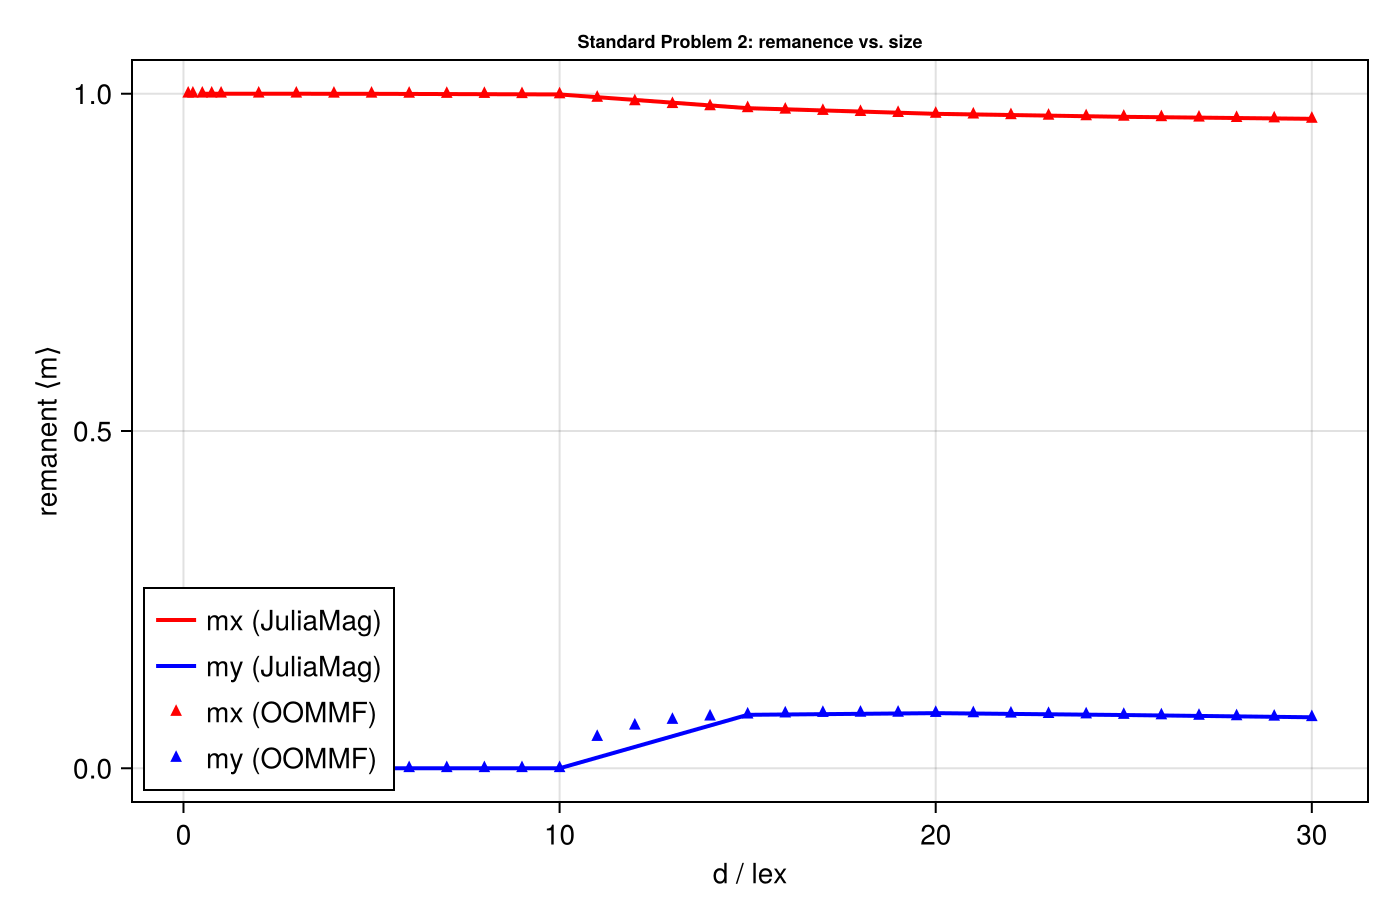

stdproblem2_hysteresis.png


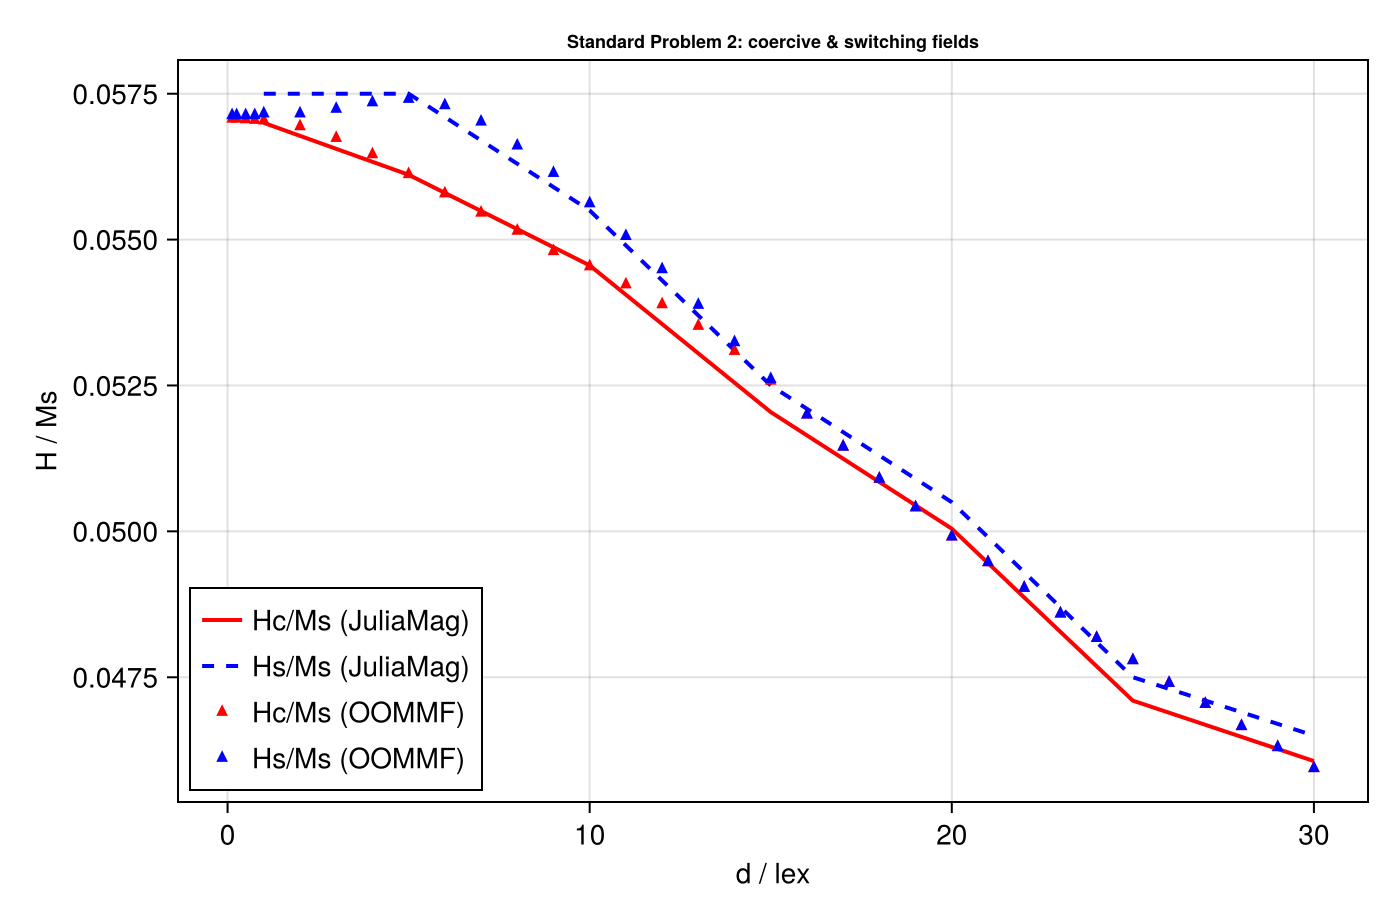

stdproblem4.png


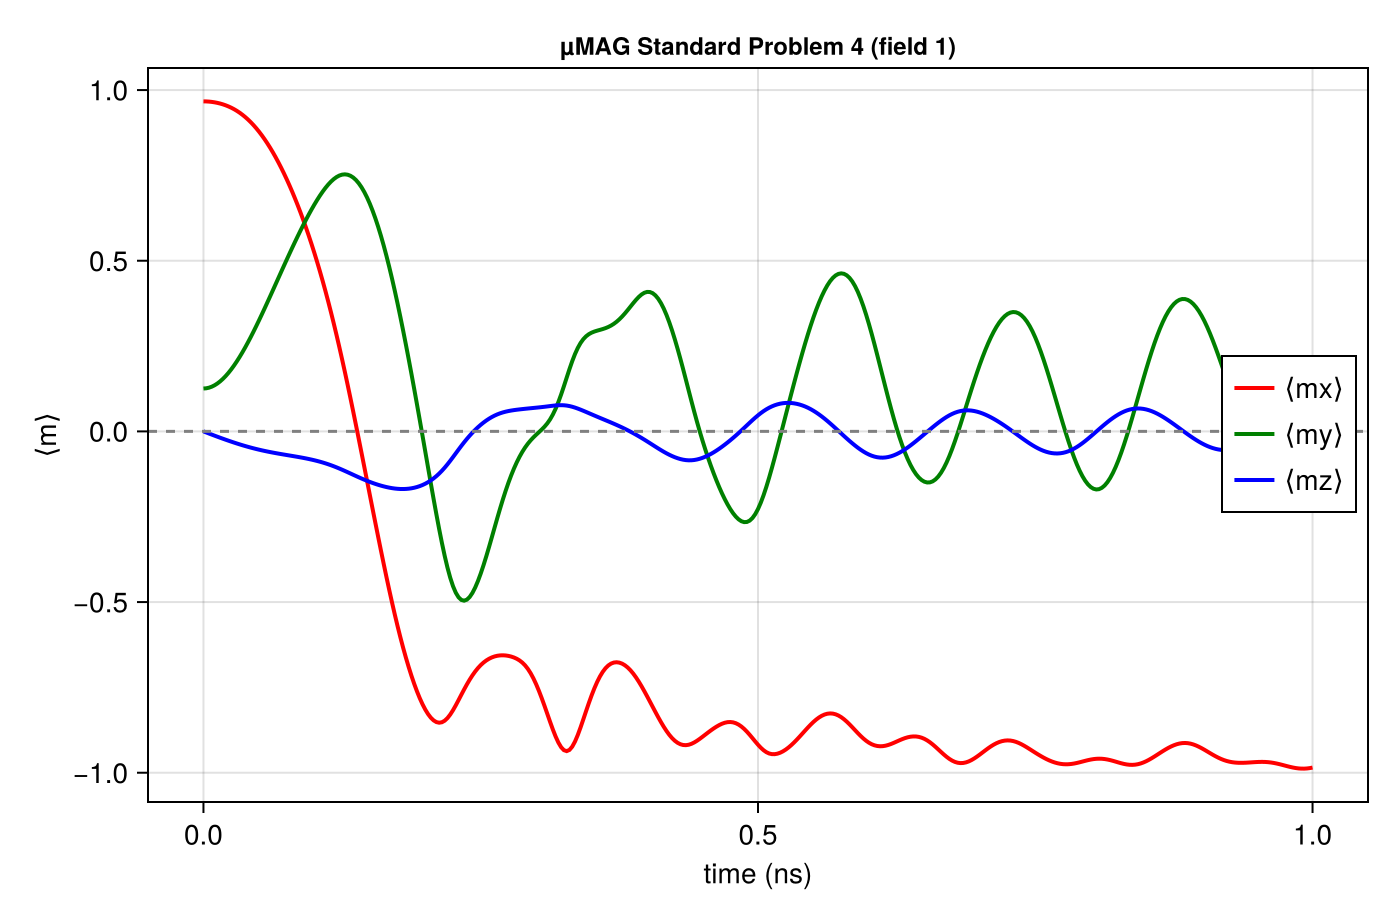

missing juliamag/examples/stdproblem5.png


In [10]:
from IPython.display import Image, display
import os
figs = ['stdproblem2_compare.png', 'stdproblem2_hysteresis.png',
        'stdproblem4.png', 'stdproblem5.png']
for f in figs:
    p = os.path.join('juliamag/examples', f)
    if os.path.exists(p):
        print(f)
        display(Image(p))
    else:
        print('missing', p)

## 7. Benchmark — full effective field (with demag) and relax, CPU vs GPU

The effective field with the FFT demag is the per-step hot loop and where the GPU
wins most. This writes a CSV and prints the speedup table.

In [11]:
%%bash
cd juliamag
cat > /tmp/bench.jl <<'EOF'
using JuliaMag, CUDA, Printf
open("colab_benchmark.csv","w") do io
  println(io, "kind,cells,cpu_ms,gpu_ms,speedup")
  # --- full effective field with demag ---
  mat = Material(Msat=8.0e5, Aex=1.3e-11, alpha=0.02, Ku=5e4, anisU=(0,0,1))
  println("Effective field (with demag):  cells   CPU(ms)  GPU(ms)  speedup")
  for (nx,ny,nz) in [(128,128,1),(256,256,1),(512,512,1),(1024,1024,1),(256,256,8),(512,512,8)]
    mesh=Mesh((nx,ny,nz),(4e-9,4e-9,4e-9))
    wc=World(mesh,mat;demag=true,Bext=(0.02,-0.01,0.0)); m=randommag!(zeromag(mesh)); Bc=similar(m)
    effectivefield!(Bc,m,wc); tc=@elapsed for _ in 1:30; effectivefield!(Bc,m,wc); end
    wg=togpu(wc); mg=togpu(m); Bg=similar(mg); CUDA.@sync effectivefield!(Bg,mg,wg)
    tg=@elapsed (for _ in 1:30; effectivefield!(Bg,mg,wg); end; CUDA.synchronize())
    @printf("  %8d  %8.2f %8.2f  %.2fx\n", nx*ny*nz, tc/30*1e3, tg/30*1e3, tc/tg)
    @printf(io, "efield,%d,%.4f,%.4f,%.3f\n", nx*ny*nz, tc/30*1e3, tg/30*1e3, tc/tg)
  end
  # --- relax (minimizer) step ---
  matr = Material(Msat=8.0e5, Aex=1.3e-11, alpha=0.5, Ku=5e4, anisU=(0,0,1))
  println("Relax step (minimizer):        cells   CPU(ms)  GPU(ms)  speedup")
  for (nx,ny,nz) in [(128,128,1),(256,256,1),(512,512,1),(1024,1024,1),(512,512,4)]
    mesh=Mesh((nx,ny,nz),(4e-9,4e-9,4e-9)); m0=setconfig(mesh,UniformConfig(1,0.2,0.1))
    wc=World(mesh,matr;demag=true); mnc=Minimizer(wc,copy(m0)); for _ in 1:3; JuliaMag.minimizestep!(mnc); end
    tc=@elapsed for _ in 1:100; JuliaMag.minimizestep!(mnc); end
    wg=togpu(World(mesh,matr;demag=true)); mng=Minimizer(wg,togpu(copy(m0))); JuliaMag.minimizestep!(mng); CUDA.synchronize()
    tg=@elapsed (for _ in 1:100; JuliaMag.minimizestep!(mng); end; CUDA.synchronize())
    @printf("  %8d  %8.2f %8.2f  %.2fx\n", nx*ny*nz, tc/100*1e3, tg/100*1e3, tc/tg)
    @printf(io, "relax,%d,%.4f,%.4f,%.3f\n", nx*ny*nz, tc/100*1e3, tg/100*1e3, tc/tg)
  end
end
println("wrote colab_benchmark.csv")
EOF
julia --project=. /tmp/bench.jl

Effective field (with demag):  cells   CPU(ms)  GPU(ms)  speedup
     16384      3.35     2.87  1.17x
     65536     16.73     5.00  3.35x
    262144     87.25    12.22  7.14x
   1048576    584.98    39.02  14.99x
    524288    390.96    31.70  12.33x
   2097152   1674.75   119.26  14.04x
Relax step (minimizer):        cells   CPU(ms)  GPU(ms)  speedup
     16384      5.80     2.96  1.96x
     65536     22.74     9.05  2.51x
    262144    107.57    17.17  6.26x
   1048576    603.92    58.12  10.39x
   1048576    682.45    82.72  8.25x
wrote colab_benchmark.csv


In [ ]:
%%bash
cd juliamag
# SP2 (remanence) and SP2 hysteresis, SP4 dynamics — the repo drivers already
# write a .txt table and a .png figure each. Run them under the main project.
julia --project=. examples/stdproblem2.jl
julia --project=. examples/stdproblem2_hysteresis.jl
julia --project=. examples/stdproblem4.jl

# SP5 (Zhang-Li STT): relax a vortex, drive it with a current for 1 ns, and write
# the trajectory table + figure (the repo driver only prints the final ).
# NOTE: the script is written to /tmp, so `include` of the shim must use an
# absolute path (pwd() is .../juliamag from the `cd` above); a relative path would
# resolve against /tmp and fail.
cat > /tmp/sp5.jl <<'EOF'
using JuliaMag, Printf
include(joinpath(pwd(), "examples", "makie_shim.jl"))
mesh = Mesh((32,32,4), (100e-9/32, 100e-9/32, 10e-9/4))
mat  = Material(Msat=800e3, Aex=13e-12, alpha=0.1, pol=1.0, xi=0.05)
world = World(mesh, mat; demag=true)
m = setconfig(mesh, VortexConfig(mesh; circ=1, pol=1))
mn = Minimizer(world, m; stopdm=1e-6); minimize!(mn; maxsteps=20000); m = mn.m
@printf("relaxed vortex, =(%.4f,%.4f,%.4f)\n", average(m)...)

rhs!(dm,mm) = (B=world._Bbuf; effectivefield!(B,mm,world); torque!(dm,mm,B,mat.alpha);
               zhanglitorque!(dm,mm,mesh,mat,(1e12,0.0,0.0); add=true); dm)
function rk4!(m,dt,n)
  k1=similar(m);k2=similar(m);k3=similar(m);k4=similar(m);t=similar(m)
  for _ in 1:n
    rhs!(k1,m); @. t=m+0.5dt*k1; normalize!(t); rhs!(k2,t)
    @. t=m+0.5dt*k2; normalize!(t); rhs!(k3,t); @. t=m+dt*k3; normalize!(t); rhs!(k4,t)
    @. m=m+(dt/6)*(k1+2k2+2k3+k4); normalize!(m)
  end
end
dt=5e-14; nchunk=50; per=round(Int,1e-9/dt)÷nchunk
ts=Float64[]; mxs=Float64[]; mys=Float64[]; mzs=Float64[]; cx=Float64[]; cy=Float64[]
for c in 0:nchunk
  c>0 && rk4!(m,dt,per)
  a=average(m); vx,vy,_,_=vortexcore(m,mesh)
  push!(ts,c*per*dt); push!(mxs,a[1]); push!(mys,a[2]); push!(mzs,a[3]); push!(cx,vx); push!(cy,vy)
end
open("examples/stdproblem5.txt","w") do io
  println(io,"# muMAG Standard Problem 5 — JuliaMag (Zhang-Li STT)")
  println(io,"# t[s]\tmx\tmy\tmz\tcore_x[m]\tcore_y[m]")
  for i in eachindex(ts); @printf(io,"%.6e\t%.6f\t%.6f\t%.6f\t%.4e\t%.4e\n",ts[i],mxs[i],mys[i],mzs[i],cx[i],cy[i]); end
end
ref=(-0.23480,-0.09454,0.02296)
@printf("JuliaMag (1ns)=(%.5f,%.5f,%.5f)  mumax3=(%.5f,%.5f,%.5f)  Δ=(%.1e,%.1e,%.1e)\n",
        mxs[end],mys[end],mzs[end], ref..., mxs[end]-ref[1],mys[end]-ref[2],mzs[end]-ref[3])
tns=ts.*1e9
p1=plot(tns,[mxs mys mzs]; label=["mx" "my" "mz"], lw=2, xlabel="t (ns)", ylabel="⟨m⟩",
        title="SP5: Zhang-Li STT", titlefontsize=10)
savefig(p1, "examples/stdproblem5.png")
p2=plot(cx.*1e9,cy.*1e9; marker=:circle, ms=2, legend=false, xlabel="core x (nm)",
        ylabel="core y (nm)", title="vortex core path", titlefontsize=10)
savefig(p2, "examples/stdproblem5_core.png")
println("wrote examples/stdproblem5.txt, stdproblem5.png, stdproblem5_core.png")
EOF
julia --project=. /tmp/sp5.jl

In [ ]:
from IPython.display import Image, display
import os
figs = ['stdproblem5.png']
for f in figs:
    p = os.path.join('juliamag/examples', f)
    if os.path.exists(p):
        print(f)
        display(Image(p))
    else:
        print('missing', p)

## 8. Plot the speedup

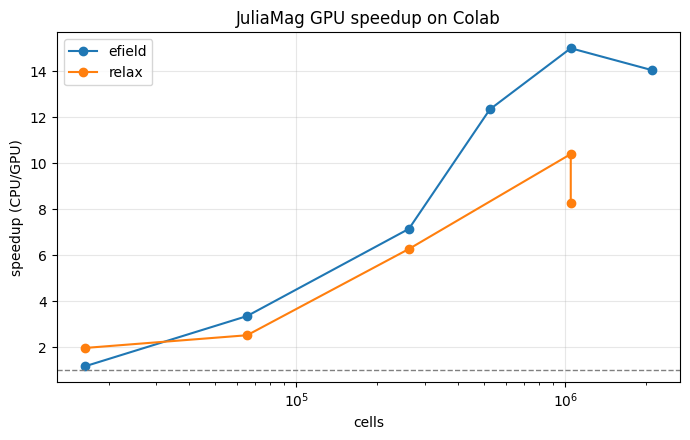

,kind,cells,cpu_ms,gpu_ms,speedup
0,efield,16384,3.3477,2.8692,1.167
1,efield,65536,16.7279,4.9970,3.348
2,efield,262144,87.2501,12.2195,7.140
3,efield,1048576,584.9790,39.0182,14.992
4,efield,524288,390.9596,31.7004,12.333
5,efield,2097152,1674.7537,119.2589,14.043
6,relax,16384,5.7982,2.9557,1.962
7,relax,65536,22.7426,9.0464,2.514
8,relax,262144,107.5720,17.1704,6.265
9,relax,1048576,603.9156,58.1193,10.391


In [12]:
import pandas as pd, matplotlib.pyplot as plt
df = pd.read_csv('juliamag/colab_benchmark.csv')
fig, ax = plt.subplots(figsize=(7,4.5))
for kind, g in df.groupby('kind'):
    g = g.sort_values('cells')
    ax.plot(g['cells'], g['speedup'], marker='o', label=kind)
ax.axhline(1.0, color='gray', ls='--', lw=1)
ax.set_xscale('log'); ax.set_xlabel('cells'); ax.set_ylabel('speedup (CPU/GPU)')
ax.set_title('JuliaMag GPU speedup on Colab'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('juliamag/colab_speedup.png', dpi=120); plt.show()
df

## 9. Stage 2 — extra problems from the magnum.np demos

A second round of validation problems adapted from
[magnum.np](https://gitlab.com/magnum.np/magnum.np)'s `demos/`, covering physics
beyond the µMAG standard problems (see `docs/stage2_problems.md`). This runs the
ones JuliaMag supports today, each saving a table + figure:

- **Langevin** (`demos/langevin`) — an ensemble of uncoupled macrospins at finite
  T; ⟨mx⟩ vs field follows the Langevin function L(ξ) (fluctuation–dissipation).
- **Domain-wall depinning** (`demos/sp_domainwall_pinning`) — a soft/hard region
  interface; ramp the field and find the depinning field (≈1.4–1.8 T).
- **Bulk-DMI spin spiral** (`demos/dmi`) — a helix of period L = 4πA/D on a
  periodic chain; the relaxed period matches the analytic value.

Problems that need features JuliaMag does not have yet (spin-orbit torque with
separate damping/field-like terms, FMR/dispersion spectra, eigenmodes, energy
barriers/NEB, RKKY, magnetoelasticity, eddy currents) are listed in
`docs/stage2_problems.md` as future work.

In [ ]:
%%bash
cd juliamag
julia --project=. examples/stage2_local.jl

In [ ]:
from IPython.display import Image, display
import os
for f in ['stage2_langevin.png', 'stage2_depinning.png', 'stage2_dmi_spiral.png']:
    p = os.path.join('juliamag/examples', f)
    if os.path.exists(p):
        print(f); display(Image(p))
    else:
        print('missing', p)

## 10. Download the results

Saves the benchmark CSV and speedup plot, the Standard Problem 4 GPU outputs,
every standard problem's data table and figure, and the Stage-2 problem outputs.

In [ ]:
from google.colab import files
outputs = [
    # GPU benchmark
    'juliamag/colab_benchmark.csv', 'juliamag/colab_speedup.png',
    # Standard Problem 4 on the GPU
    'juliamag/examples/stdproblem4_gpu.txt', 'juliamag/examples/stdproblem4_gpu.png',
    # Standard problems: tables + figures
    'juliamag/examples/stdproblem2.txt', 'juliamag/examples/stdproblem2_compare.png',
    'juliamag/examples/stdproblem2_hysteresis.txt', 'juliamag/examples/stdproblem2_hysteresis.png',
    'juliamag/examples/stdproblem4.txt', 'juliamag/examples/stdproblem4.png',
    'juliamag/examples/stdproblem5.txt', 'juliamag/examples/stdproblem5.png',
    'juliamag/examples/stdproblem5_core.png',
    # Stage-2 problems (magnum.np demos)
    'juliamag/examples/stage2_langevin.txt', 'juliamag/examples/stage2_langevin.png',
    'juliamag/examples/stage2_depinning.txt', 'juliamag/examples/stage2_depinning.png',
    'juliamag/examples/stage2_dmi_spiral.txt', 'juliamag/examples/stage2_dmi_spiral.png',
]
for f in outputs:
    try:
        files.download(f)
    except Exception as e:
        print('skip', f, e)